In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Set the global font size to 7 pt
plt.rcParams.update({
    'font.size': 7, 
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
})

cm_to_inch = 1 / 2.54
length = width = 7
length  = 14.26 
figsize_cm = (length * cm_to_inch, width * cm_to_inch)  # (9cm, 9cm)

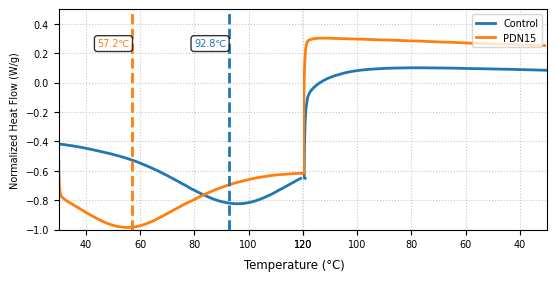

In [3]:
# Create the figure and subplots with no gap between subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize_cm,sharey=True,
                                gridspec_kw={'wspace': 0}
                              )  # wspace=0 removes the horizontal gap between subplots

df_upper = pd.read_csv('data/hotflow/control-upper.csv')
control_df_upper = df_upper[df_upper['Label'] == 'PDN15']
pdn15_df_upper = df_upper[df_upper['Label'] == 'Control']


ax1.plot(control_df_upper['Temperature (°C)'], control_df_upper['Heat Flow (Normalized)(W/g)'],
         label='Control', color='#1f77b4', linewidth=2)
ax1.plot(pdn15_df_upper['Temperature (°C)'], pdn15_df_upper['Heat Flow (Normalized)(W/g)'],
         label='PDN15', color='#ff7f0e', linewidth=2)


ax1.set_xlim(30, 120)
ax1.set_ylim(-1, 0.5)


vline_x = 92.8
ax1.axvline(x=vline_x, ymin=0, color='#1f77b4', linestyle='--', linewidth=2)
ax1.text(vline_x - 7, 0.3, f'{vline_x}℃',
         color='#1f77b4', ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

vline_x = 57.2
ax1.axvline(x=vline_x, ymin=0, color='#ff7f0e', linestyle='--', linewidth=2)
ax1.text(vline_x - 7, 0.3, f'{vline_x}℃',
         color='#ff7f0e', ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))


ax1.set_ylabel('Normalized Heat Flow (W/g)')  # Hide the y-axis label on the right subplot to avoid duplication
ax1.grid(True, linestyle=':', alpha=0.7)
# ax1.legend(loc='upper right')


df_lower = pd.read_csv('data/hotflow/control-lower.csv')
control_df_lower = df_lower[df_lower['Label'] == 'PDN15']
pdn15_df_lower = df_lower[df_lower['Label'] == 'Control']


ax2.plot(control_df_lower['Temperature (°C)'], control_df_lower['Heat Flow (Normalized)(W/g)'],
         label='Control', color='#1f77b4', linewidth=2)
ax2.plot(pdn15_df_lower['Temperature (°C)'], pdn15_df_lower['Heat Flow (Normalized)(W/g)'],
         label='PDN15', color='#ff7f0e', linewidth=2)


ax2.set_xlim(30, 120)
ax2.set_ylim(-1, 0.5)
# Move the y-axis ticks to the right side
ax2.tick_params(axis='y', which='both', 
               left=False,        # Hide left ticks
               right=False,        # Show right ticks
               labelleft=False,   # Hide left labels
               labelright=False)   # Show right labels


ax2.spines['left'].set_visible(False)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(loc='upper right')
ax2.invert_xaxis()
fig.supxlabel('Temperature (°C)', x=0.5, y=-0.03)

plt.subplots_adjust(wspace=0.1) 

plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.12)


plt.savefig("combined_plot.svg", dpi=300, bbox_inches='tight')
plt.show()
